# Chapter 5: Sheaves, Cohomology, and the de Rham Theorem

**Source Span.** `Foundations of Differentiable Manifolds and Lie Groups.pdf` printed pages `163-219`, covering sheaves and presheaves, cochain complexes, axiomatic sheaf cohomology, classical cohomology theories, Alexander-Spanier, de Rham, singular and Cech cohomology, the de Rham theorem, multiplicative structure, supports, and exercises.

**Chapter Goal.** Understand why different cohomology theories on manifolds compute the same information. Sheaves organize local data and restriction maps. Cochain complexes turn local-to-global consistency into algebra. Fine resolutions make sheaf cohomology computable. The de Rham theorem identifies differential-form cohomology with singular cohomology through integration, and multiplicative structures compare wedge and cup products.

The notebook uses finite models that expose the chapter's proof architecture: a sheaf restriction diagram, explicit coboundary matrices with `d^2=0`, a good cover of the circle whose Cech cohomology has one one-dimensional class, a period representative for the de Rham map, and a dependency graph for the comparison theorem.


In [1]:
from pathlib import Path
import json, math, sys
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
import plotly.graph_objects as go
BOOK_ROOT=None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists(): BOOK_ROOT=candidate; break
if BOOK_ROOT is None: raise RuntimeError('book root not found')
if str(BOOK_ROOT) not in sys.path: sys.path.insert(0,str(BOOK_ROOT))
from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html
UNIT_KEY='chapter-05-sheaves-cohomology-and-the-de-rham-theorem'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES,HTML,CHECKS,TABLES=(ARTIFACT_ROOT/name for name in ['figures','html','checks','tables'])
TRACKED_ARTIFACTS=[]
print(f'Book root: {BOOK_ROOT}')


Book root: D:\Geometry\Foundations-of-Differentiable-Manifolds-and-Lie-Groups


## Visual Storyboard

1. **Sheaf restriction diagram.** Open sets and overlaps are represented as a directed restriction graph; compatible local sections glue when their overlap values agree.
2. **Cochain complex sanity check.** Coboundary matrices are displayed and `d^2=0` is checked exactly.
3. **Cech cohomology of a circle cover.** A three-arc good cover has nerve a cycle; the incidence matrix gives one independent one-cocycle class.
4. **de Rham integration map.** The angular form has period one after normalization, matching the generator of first cohomology of the circle.
5. **Theorem dependency graph.** Fine sheaves, resolutions, classical theories, de Rham forms, singular cochains, products, and supports are tied into a proof map.

## Library Routing

| Concept | Representation | Library | Why it fits | Check |
| --- | --- | --- | --- | --- |
| Sheaves | Restriction/gluing graph | NetworkX + Matplotlib | Sheaves are local data with restriction arrows | overlap compatibility |
| Cochain complexes | Integer matrices | SymPy + CSV | Exact matrix algebra shows `d^2=0` | coboundary product zero |
| Cech cohomology | Good cover nerve of circle | NetworkX + SymPy | A finite nerve captures the cover calculation | `dim H1=1` |
| de Rham theorem | Period integral | NumPy + Plotly | Integration is the comparison map | normalized period equals one |


## Sheaves And Cochain Complexes As Local-To-Global Machines

A sheaf attaches algebraic data to open sets and provides restriction maps to smaller open sets. The sheaf condition says compatible local sections glue uniquely. Cohomology measures the failure of local data to be globally trivial. Warner develops this through cochain complexes and exactness, so the finite diagram below records both the restriction picture and the matrix condition `d^2=0`.


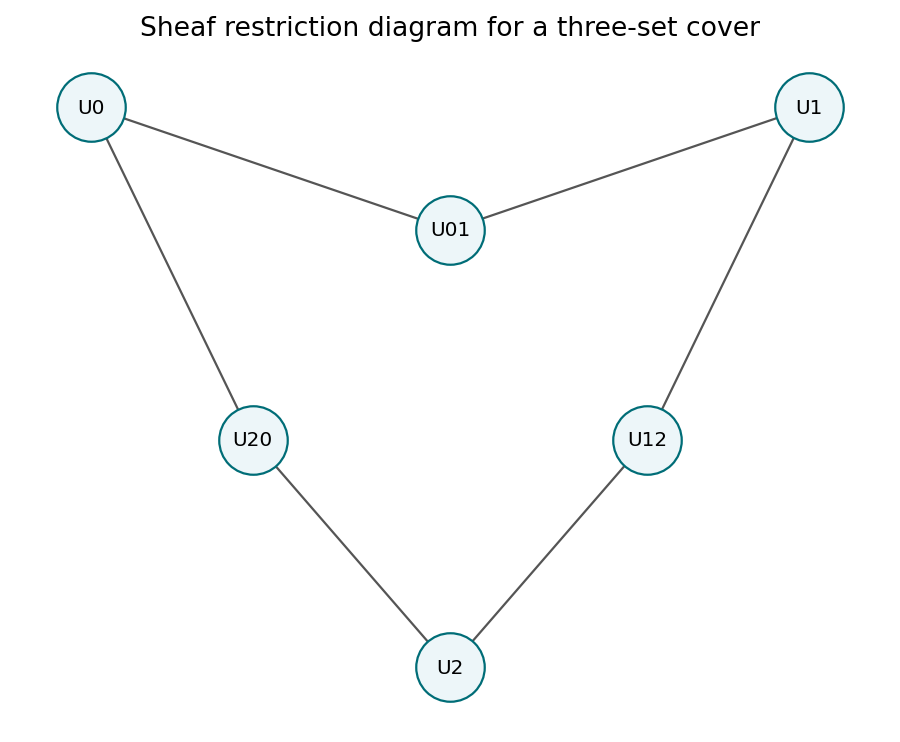

{'compatible': True}

In [2]:
G=nx.DiGraph(); edges=[('U0','U01'),('U1','U01'),('U1','U12'),('U2','U12'),('U2','U20'),('U0','U20')]
G.add_edges_from(edges); pos={'U0':(-1,.8),'U1':(1,.8),'U2':(0,-.8),'U01':(0,.45),'U12':(.55,-.15),'U20':(-.55,-.15)}
local_sections={'U0':2.0,'U1':2.0,'U2':2.0,'U01':2.0,'U12':2.0,'U20':2.0}
compatible=all(abs(local_sections[a]-local_sections[b])<1e-12 for a,b in [('U0','U01'),('U1','U01'),('U1','U12'),('U2','U12'),('U2','U20'),('U0','U20')])
fig,ax=plt.subplots(figsize=(7,5.5)); nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle='-|>',edge_color='#555'); nx.draw_networkx_nodes(G,pos,ax=ax,node_color='#edf6f9',edgecolors='#006d77',node_size=950); nx.draw_networkx_labels(G,pos,ax=ax,font_size=9); ax.set_title('Sheaf restriction diagram for a three-set cover'); ax.axis('off')
sheaf_path=save_matplotlib(fig, FIGURES/'sheaf-restriction-gluing-diagram.png'); plt.close(fig)
sheaf_json=save_json({'restriction_edges':edges,'compatible_constant_sections':compatible}, CHECKS/'sheaf-restriction-gluing-diagram.json')
TRACKED_ARTIFACTS.extend([sheaf_path,sheaf_json]); display_artifact(sheaf_path,width=680)
{'compatible':compatible}


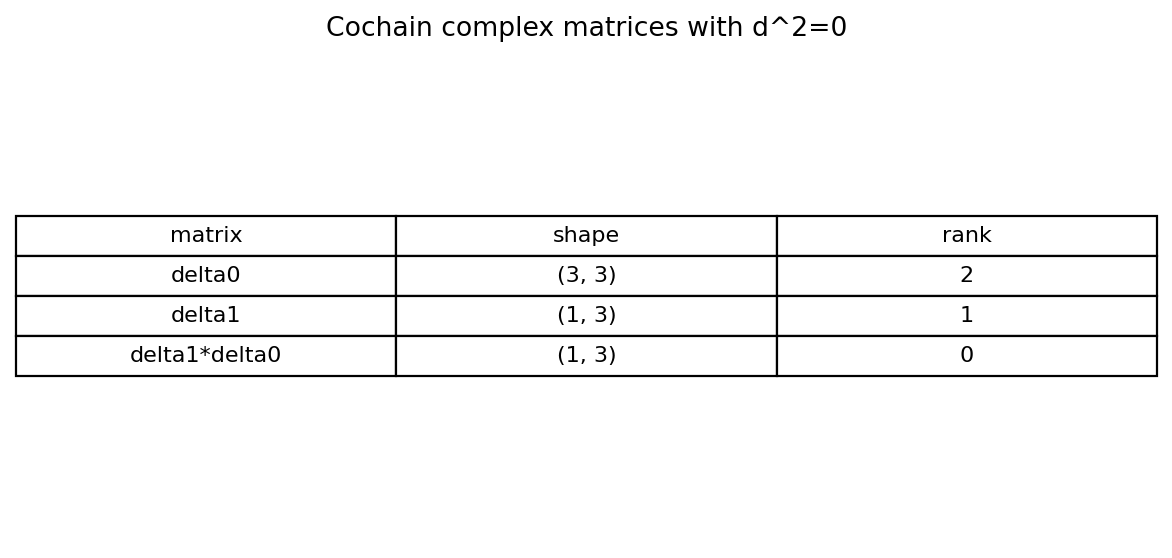

[{'matrix': 'delta0', 'shape': '(3, 3)', 'rank': 2},
 {'matrix': 'delta1', 'shape': '(1, 3)', 'rank': 1},
 {'matrix': 'delta1*delta0', 'shape': '(1, 3)', 'rank': 0}]

In [3]:
# Filled triangle cochain complex: C0 -> C1 -> C2, with oriented edges 01,12,20 and face 012.
delta0=sp.Matrix([[-1,1,0],[0,-1,1],[1,0,-1]])
delta1=sp.Matrix([[1,1,1]])
d_squared=delta1*delta0
rank_delta0=delta0.rank(); rank_delta1=delta1.rank()
rows=[{'matrix':'delta0','shape':str(delta0.shape),'rank':int(rank_delta0)},{'matrix':'delta1','shape':str(delta1.shape),'rank':int(rank_delta1)},{'matrix':'delta1*delta0','shape':str(d_squared.shape),'rank':int(d_squared.rank())}]
complex_csv=save_csv(rows, TABLES/'cochain-complex-d-squared-zero.csv')
complex_json=save_json({'delta0':[[int(v) for v in row] for row in delta0.tolist()],'delta1':[[int(v) for v in row] for row in delta1.tolist()],'d_squared':[[int(v) for v in row] for row in d_squared.tolist()],'d_squared_zero':bool(d_squared==sp.zeros(1,3))}, CHECKS/'cochain-complex-d-squared-zero.json')
TRACKED_ARTIFACTS.extend([complex_csv,complex_json])
fig,ax=plt.subplots(figsize=(8,4)); ax.axis('off'); table=ax.table(cellText=[[r['matrix'],r['shape'],r['rank']] for r in rows],colLabels=['matrix','shape','rank'],loc='center',cellLoc='center'); table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.15,1.5); ax.set_title('Cochain complex matrices with d^2=0')
complex_path=save_matplotlib(fig, FIGURES/'cochain-complex-d-squared-zero.png'); plt.close(fig); TRACKED_ARTIFACTS.append(complex_path); display_artifact(complex_path,width=720)
rows


## Cech And de Rham On The Circle

A good cover lets sheaf cohomology be computed by a finite nerve. For a circle covered by three arcs with pairwise overlaps and no triple overlap, the nerve is a cycle graph. Its first Cech cohomology has dimension one. The de Rham side has the normalized angular form `dtheta/(2pi)`, whose integral around the circle is one. This is the smallest visible model of the de Rham theorem's comparison map by integration.


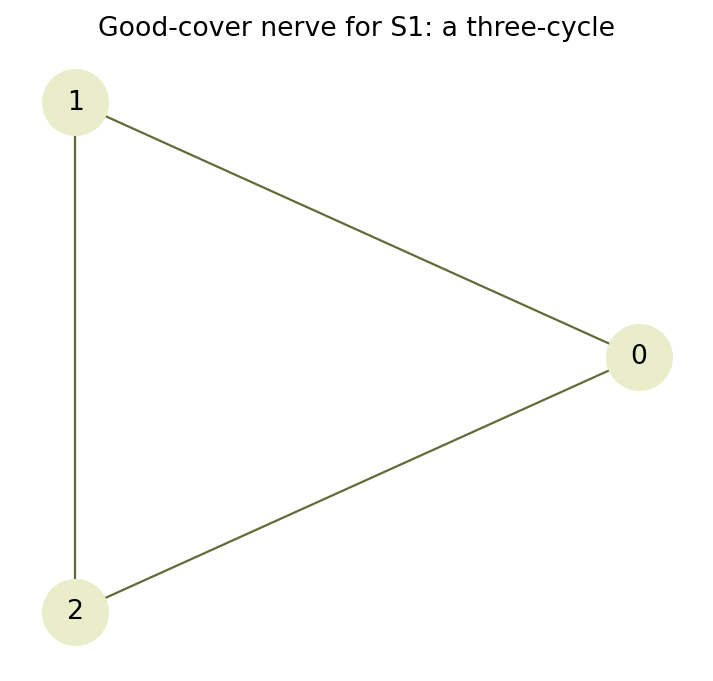

{'H1_dim': 1}

In [4]:
# Cycle nerve: C0 dimension 3, C1 dimension 3, no C2. H1 = C1 / im(delta0), rank = 3-rank(delta0)=1.
incidence=sp.Matrix([[-1,1,0],[0,-1,1],[1,0,-1]])
h1_dim=3-incidence.rank()
cycle=nx.cycle_graph(3); pos=nx.circular_layout(cycle)
fig,ax=plt.subplots(figsize=(5.5,5)); nx.draw_networkx(cycle,pos,ax=ax,node_color='#e9edc9',edge_color='#606c38',node_size=850,with_labels=True); ax.set_title('Good-cover nerve for S1: a three-cycle'); ax.axis('off')
cech_path=save_matplotlib(fig, FIGURES/'cech-good-cover-circle-nerve.png'); plt.close(fig)
cech_json=save_json({'model':'three-open-set good cover of S1 with cyclic nerve','C0_dim':3,'C1_dim':3,'rank_delta0':int(incidence.rank()),'H1_dim':int(h1_dim),'interpretation':'one independent one-cocycle class'}, CHECKS/'cech-good-cover-circle-nerve.json')
TRACKED_ARTIFACTS.extend([cech_path,cech_json]); display_artifact(cech_path,width=560)
{'H1_dim':h1_dim}


In [5]:
th=np.linspace(0,2*np.pi,3001); normalized_integrand=np.full_like(th,1/(2*math.pi)); period=float(np.trapezoid(normalized_integrand,th))
fig=go.Figure(); fig.add_trace(go.Scatter(x=np.cos(th),y=np.sin(th),mode='lines',name='cycle')); fig.add_trace(go.Scatter(x=[1],y=[0],mode='markers+text',text=['start/end'],textposition='top center'))
fig.update_layout(title='de Rham comparison: normalized angular form integrates to 1 on S1',width=680,height=600,yaxis_scaleanchor='x')
drh_html=save_plotly_html(fig, HTML/'de-rham-period-map-circle.html')
drh_json=save_json({'normalized_period':period,'cech_H1_dim':h1_dim,'period_matches_generator':abs(period-1)<1e-8}, CHECKS/'de-rham-period-map-circle.json')
TRACKED_ARTIFACTS.extend([drh_html,drh_json]); display_artifact(drh_html,width=720,height=600)
{'period':period}


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'period': 1.0}

## Source Coverage Notes

The sheaf part of the chapter should be read as a formal local-to-global machine. A presheaf has restriction maps; a sheaf adds the gluing axiom. Fine sheaves are especially useful on manifolds because partitions of unity make them acyclic for the cohomology theory Warner builds. This is why the chapter can pass from abstract sheaf cohomology to concrete resolutions and then compare many classical theories.

The finite Cech circle model is intentionally small, but it reflects the comparison theorem's skeleton. A good cover turns local overlap data into a cochain complex. The de Rham complex turns forms and the exterior derivative into another cochain complex. Integration pairs forms with singular chains and produces the de Rham homomorphism. Warner's theorem states that this map is not just a vector-space coincidence: it is canonical, compatible with products, and extensible to variants with supports.


## Applied Lab: Comparing Theories Without Losing Structure

Warner's proof does not merely compare dimensions. It builds canonical isomorphisms among cohomology theories and tracks products and supports. The finite calculations here show the core mechanics: sheaf restrictions organize local data, cochain complexes impose `d^2=0`, a good cover converts local intersections into a nerve, and integration sends de Rham classes to cochain functionals. Multiplicative structure is the statement that this comparison respects the product: wedge product on forms corresponds to cup product on cochains.


## Learner Inspection Targets

The most important thing to inspect is not the size of the finite examples but the shape of the maps. Restriction arrows go from larger open sets to smaller overlaps. Coboundary maps go from lower-degree cochains to higher-degree cochains and must compose to zero. The Cech nerve turns intersections of open sets into combinatorics. The de Rham period turns a differential form into a number assigned to a cycle. These are the arrows that Warner proves are compatible across theories.

The product and support portions of the chapter are represented in the dependency graph because they are structural refinements. A cohomology comparison is weaker if it loses products or ignores compact supports; Warner tracks both.


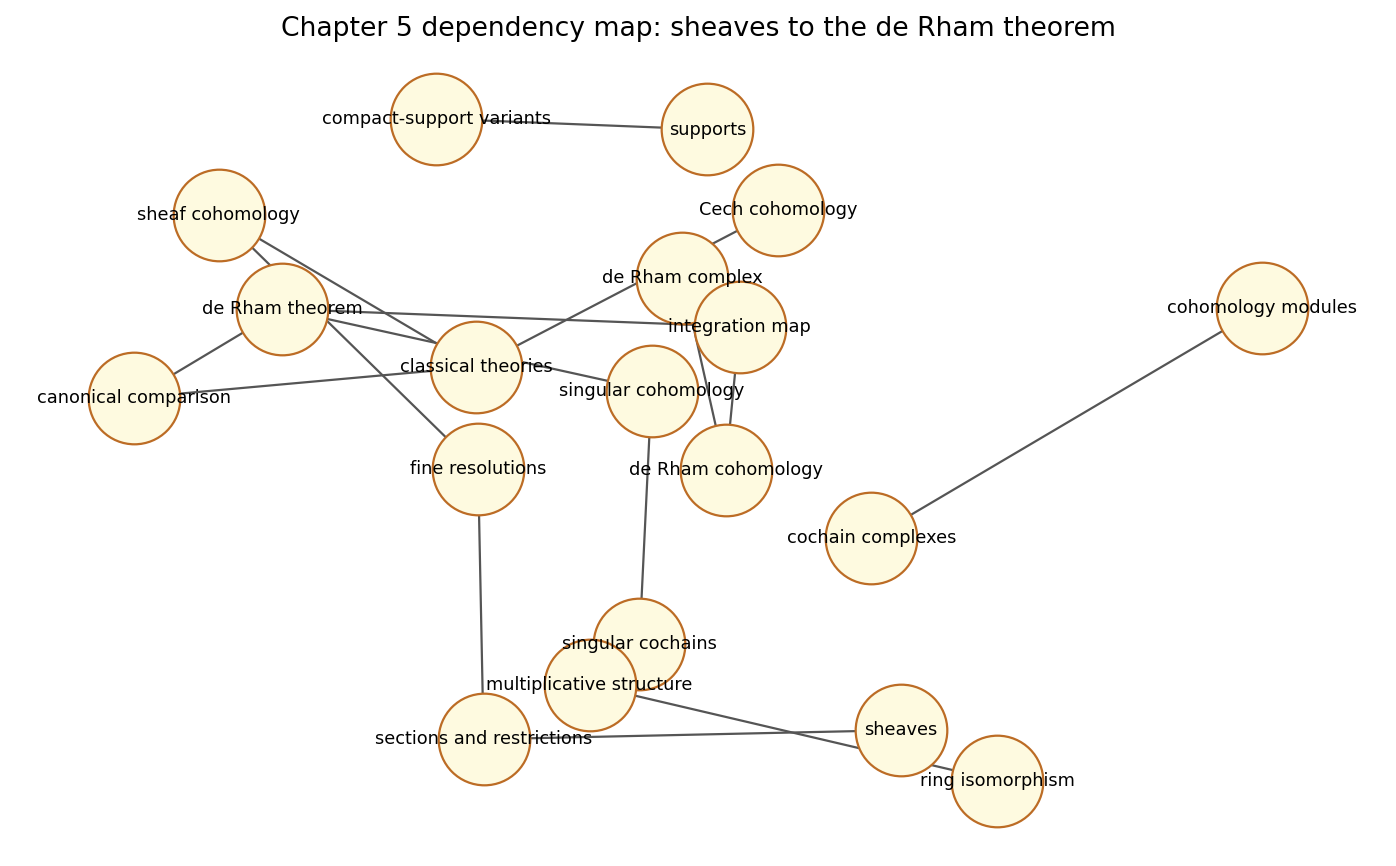

{'nodes': 19, 'edges': 15}

In [6]:
D=nx.DiGraph(); deps=[('sheaves','sections and restrictions'),('sections and restrictions','fine resolutions'),('cochain complexes','cohomology modules'),('fine resolutions','sheaf cohomology'),('sheaf cohomology','classical theories'),('classical theories','canonical comparison'),('canonical comparison','de Rham theorem'),('de Rham complex','de Rham cohomology'),('singular cochains','singular cohomology'),('integration map','de Rham theorem'),('de Rham cohomology','integration map'),('singular cohomology','de Rham theorem'),('Cech cohomology','classical theories'),('multiplicative structure','ring isomorphism'),('supports','compact-support variants')]
D.add_edges_from(deps); pos=nx.spring_layout(D,seed=505,k=.8)
fig,ax=plt.subplots(figsize=(11,6.5)); nx.draw_networkx_edges(D,pos,ax=ax,arrows=True,arrowstyle='-|>',edge_color='#555'); nx.draw_networkx_nodes(D,pos,ax=ax,node_color='#fefae0',edgecolors='#bc6c25',node_size=1700); nx.draw_networkx_labels(D,pos,ax=ax,font_size=8); ax.axis('off'); ax.set_title('Chapter 5 dependency map: sheaves to the de Rham theorem')
dep_path=save_matplotlib(fig, FIGURES/'sheaf-cohomology-de-rham-theorem-dependency-map.png'); plt.close(fig)
dep_json=save_json({'nodes':list(D.nodes),'edges':deps,'acyclic':nx.is_directed_acyclic_graph(D)}, CHECKS/'sheaf-cohomology-de-rham-theorem-dependency-map.json')
TRACKED_ARTIFACTS.extend([dep_path,dep_json]); display_artifact(dep_path,width=840)
{'nodes':D.number_of_nodes(),'edges':D.number_of_edges()}


In [7]:
assert compatible
assert d_squared == sp.zeros(1,3)
assert h1_dim == 1
assert abs(period-1)<1e-8
assert nx.has_path(D,'sheaves','de Rham theorem')
assert_artifacts(TRACKED_ARTIFACTS,min_bytes=80)
final_sanity={'unit':UNIT_KEY,'tracked_artifacts':len(TRACKED_ARTIFACTS),'core_checks':['sheaf gluing compatibility','cochain d squared zero','Cech H1 circle','de Rham period map','comparison theorem DAG']}
final_sanity


{'unit': 'chapter-05-sheaves-cohomology-and-the-de-rham-theorem',
 'tracked_artifacts': 11,
 'core_checks': ['sheaf gluing compatibility',
  'cochain d squared zero',
  'Cech H1 circle',
  'de Rham period map',
  'comparison theorem DAG']}

## Takeaways

Sheaves are a disciplined way to encode local data and restrictions. Cochain complexes convert compatibility and obstruction into algebra. Axiomatic sheaf cohomology lets Warner compare classical theories canonically. The de Rham theorem says integration identifies differential-form cohomology with singular cohomology, and the multiplicative discussion keeps the ring structure intact. The finite circle model captures the central intuition: a differential form period and a Cech one-cocycle represent the same topological class.
